# Single-qubit deterministic benchmarking demo

This notebook compares the Gaussian and strictly resonant composite $X_\pi$ pulses. The amplitude error is injected into the sampled Hamiltonian before calculating the actual noisy gate and the sequence $[U_\epsilon U_\epsilon]^n$.

$$T_gH_\epsilon(s)=\frac12\left[(1+\epsilon)T_g\Omega_x(s)X+(1+\epsilon)T_g\Omega_y(s)Y+T_g\Delta(s)Z\right].$$

The numerical implementation is in [`db_helpers.py`](db_helpers.py).

In [1]:
from pathlib import Path
import sys

search_roots = (Path.cwd(), *Path.cwd().parents)
DEMO_DIR = next(
    path
    for root in search_roots
    for path in (root, root / "proposals/1qb-DB/1qb-DB-demo")
    if (path / "db_helpers.py").is_file()
)
sys.path.insert(0, str(DEMO_DIR))
import db_helpers as db

ERRORS = (-0.03, 0.03)
N_CYCLES = 60
WAVEFORM_DIR, metadata, pulses = db.load_experiment_inputs()
print(WAVEFORM_DIR)

/Users/wenzheng/Desktop/QElements/Gate_construction/pulse-shape-Novera/proposals/1qb-DB/X_gate_pulse_generation/waveforms


## 1. Imported control waveforms

Both controls come directly from the saved CSV files. No pulse formula is reconstructed in this notebook.

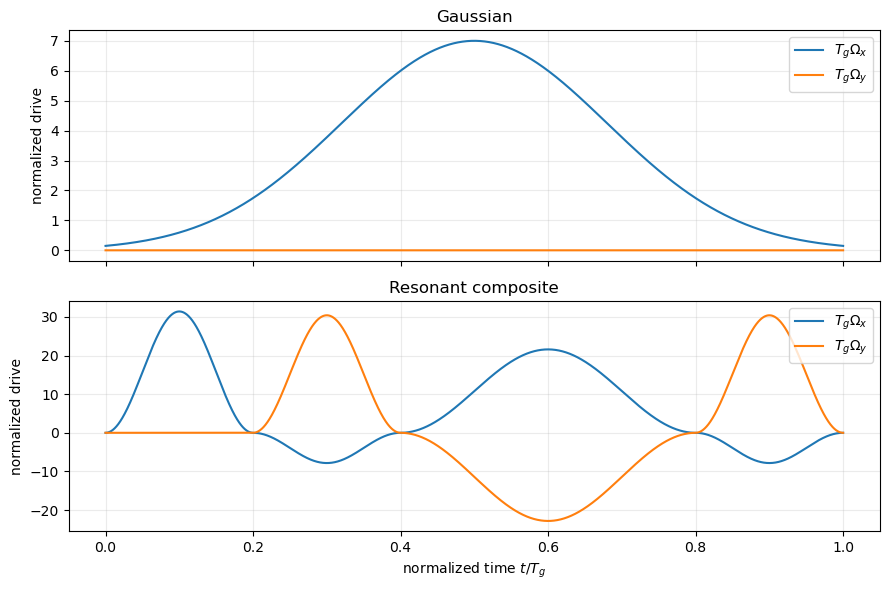

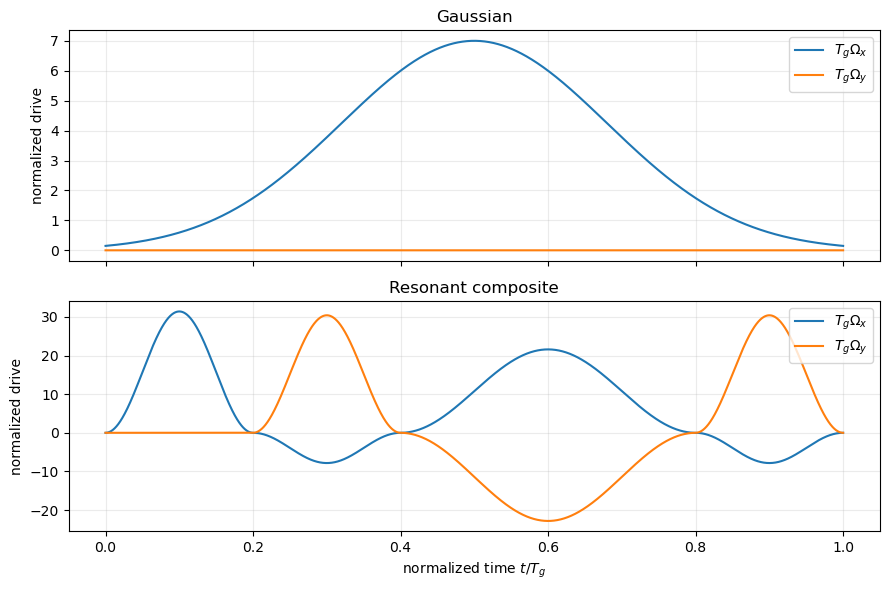

In [2]:
for name, pulse in pulses.items():
    assert abs(pulse["Tg_delta"]).max() < 1e-12, f"{name} is not resonant"
db.plot_controls(pulses)

### Error curves of the controls

The injected error is multiplicative, $H_\epsilon(s)-H_0(s)=\epsilon H_c(s)$, so the first Magnus term of the error is fixed by the *error curve*

$$R(t)=\int_0^t \vec g(s)\,\mathrm{d}s,\qquad U_0^\dagger(s)H_c(s)U_0(s)=\tfrac12\,\vec g(s)\cdot\vec\sigma,$$

where $U_0$ is the error-free propagator. The curve is calculated from the imported waveform alone, and its geometry is what makes the pulse robust:

* **closure** $|R(T_g)-R(0)|$ is the error rotation angle *per unit* $\epsilon$, so it vanishes exactly for a first-order robust pulse (a closed curve);
* the **signed area vector** $\vec A=\tfrac12\oint R\times\mathrm{d}R$, whose components $(A_{yz},A_{zx},A_{xy})$ are the areas of the three plane projections, controls the leading second-order term. The open path is closed by a straight chord back to the origin, which adds no area because $R\parallel\mathrm{d}R$ along it;
* the **curve length** is the total rotation angle: $\pi$ for a single $X_\pi$, $5\pi$ for the four-segment composite.

A third, *smooth* waveform is added here purely for comparison: `barq_resonant_screening_x_pi`, an earlier resonant candidate whose drive phase turns continuously. It is not used in sections 2–5, which keep the two selected pulses.

**How to read the shapes.** The dots mark equally spaced *times*, so their spacing shows $|\mathrm{d}R/\mathrm{d}t|=\Omega(t)$: a smooth envelope appears as a smooth dot density. But the envelope does not smooth the *shape*. Inside a segment of constant drive phase the drive axis $\hat n$ is fixed, and the rotation generated there is about that same $\hat n$, so the toggling-frame axis $\hat m$ is invariant and $R$ advances along a straight line; the path bends only where the phase turns. The composite pulse has a smooth envelope but only three phase jumps, so its error curve is exactly a four-edge polygon with edge lengths $(\pi,\pi,2\pi,\pi)$ — and because its envelope vanishes at every segment boundary, each corner is traversed at $\Omega=0$. The smooth candidate turns its phase continuously and therefore gives a genuinely curved path.

The same helper returns the standard unit-speed SCQC curve with `noise="dephasing"` (curvature $\Omega$, torsion $\dot\Phi$). That curve is smooth for all three waveforms, but it describes a different noise channel, one that none of these pulses was designed against.

pulse                     length/pi   |R(T)-R(0)|         A_yz         A_zx         A_xy          |A|
----------------------------------------------------------------------------------------------------
Gaussian                   1.000000  3.141593e+00   0.0000e+00   0.0000e+00   0.0000e+00   0.0000e+00
Resonant composite         5.000000  4.698811e-03  -1.6804e-13   4.5769e-14  -5.2987e-03   5.2987e-03
BARQ resonant (smooth)     3.432529  2.170721e-01   1.8070e+00  -4.4792e-01   3.2348e+00   3.7323e+00

first-order error angle per gate, epsilon*|R(T)-R(0)|:
Gaussian                 epsilon=-3%: 9.425e-02 rad  epsilon=+3%: 9.425e-02 rad
Resonant composite       epsilon=-3%: 1.410e-04 rad  epsilon=+3%: 1.410e-04 rad
BARQ resonant (smooth)   epsilon=-3%: 6.512e-03 rad  epsilon=+3%: 6.512e-03 rad


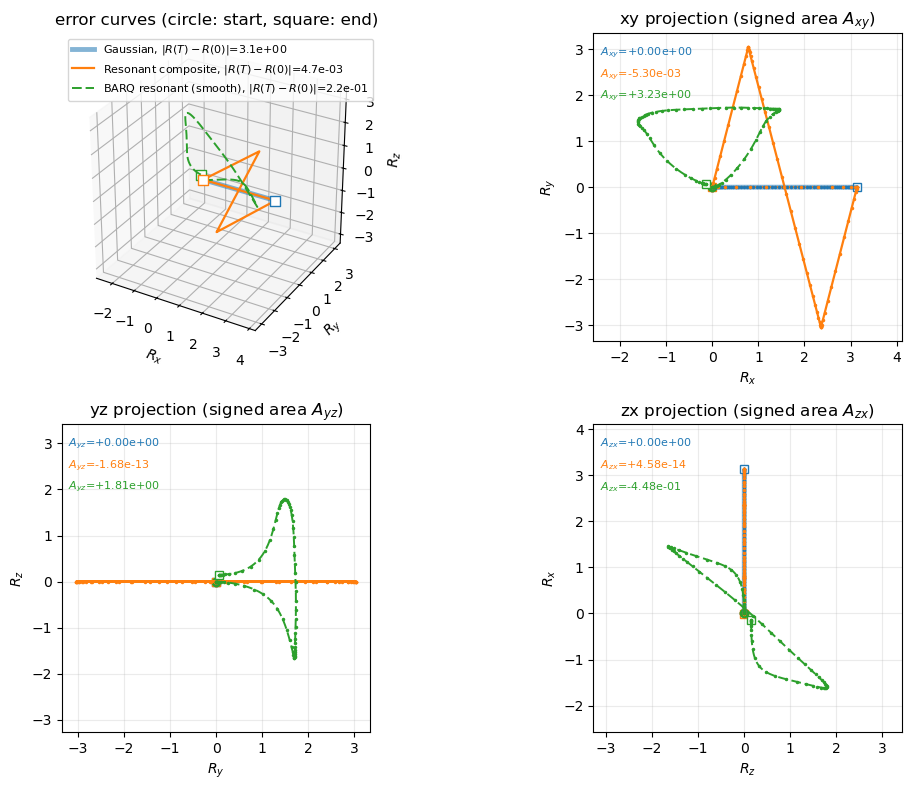

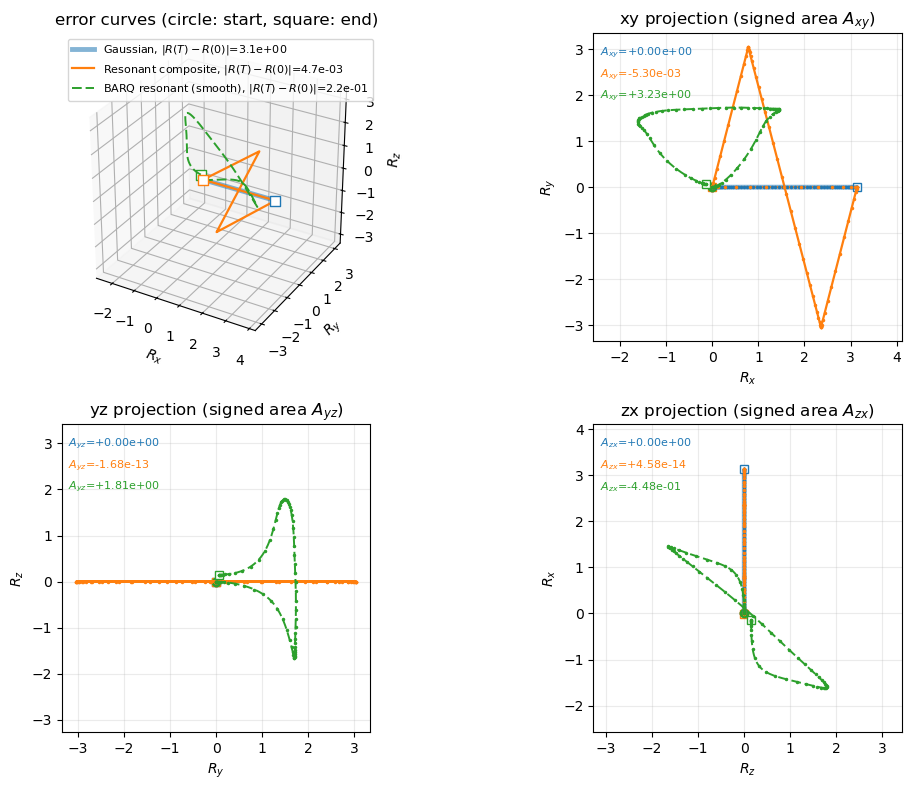

In [3]:
curve_pulses = {
    **pulses,
    "BARQ resonant (smooth)": db.load_waveform(
        "barq_resonant_screening_x_pi.csv"
    ),
}
for name, pulse in curve_pulses.items():
    assert abs(pulse["Tg_delta"]).max() < 1e-12, f"{name} is not resonant"

curves = db.calculate_error_curves(curve_pulses)
db.print_error_curve_report(curves, ERRORS)
db.plot_error_curves(curves)

## 2. Error injection and time-ordered gate

For each sampled interval, the helper constructs $H_{\epsilon,j}$, calculates
$U_j=\exp(-iH_{\epsilon,j}\Delta s_j)$, and forms
$U_\epsilon(T_g)=U_N\cdots U_2U_1$. The DB result therefore comes from the full waveform Hamiltonian.

In [22]:
gates = db.calculate_gates(pulses, ERRORS)
for name in pulses:
    fidelity = db.average_gate_fidelity(gates[name][0.0])
    print(f"{name:20s} zero-error fidelity = {fidelity:.12f}")

Gaussian             zero-error fidelity = 1.000000000000
Resonant composite   zero-error fidelity = 1.000000000000


## 3. Actual noisy gates

These are the numerical gate matrices obtained after injecting $\epsilon=\pm3\%$ into the Hamiltonian.

In [23]:
db.print_gate_report(gates, ERRORS)


Gaussian
epsilon=-3%, ||U_dagger U-I||=5.97e-15
[[0.0471065+0.j        0.       -0.9988899j]
 [0.       -0.9988899j 0.0471065+0.j       ]]
epsilon=+3%, ||U_dagger U-I||=1.26e-15
[[-0.0471064+0.j         0.       -0.9988899j]
 [ 0.       -0.9988899j -0.0471064+0.j       ]]

Resonant composite
epsilon=-3%, ||U_dagger U-I||=7.09e-15
[[ 0.0000164+0.0000001j -0.       -1.j       ]
 [ 0.       -1.j         0.0000164-0.0000001j]]
epsilon=+3%, ||U_dagger U-I||=1.46e-14
[[-0.0000164-0.0000001j -0.       -1.j       ]
 [ 0.       -1.j        -0.0000164+0.0000001j]]


## 4. Deterministic-benchmarking comparison

Both pulses are shown on one graph. Color identifies the pulse. The connected open circles identify $-3\%$; the thicker solid lines identify $+3\%$. The markers remain visible when the two error signs overlap.

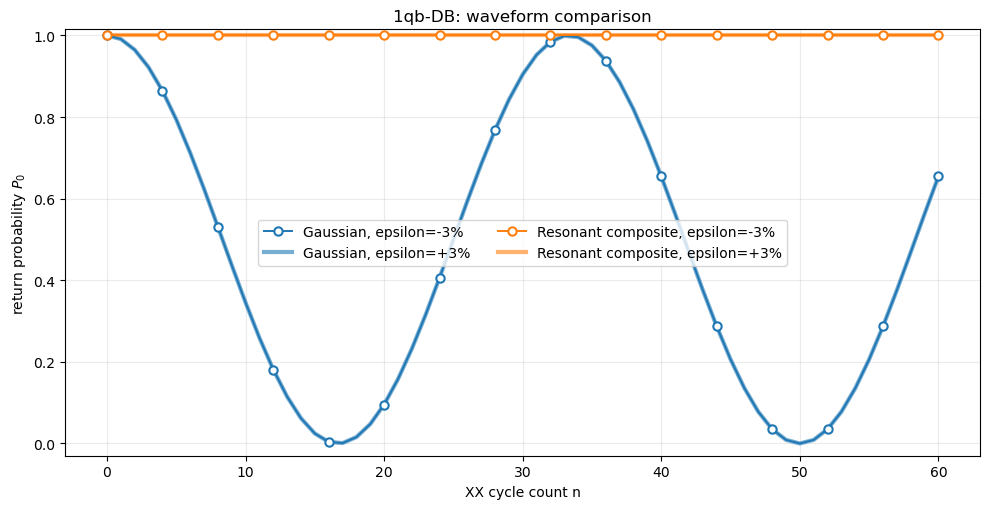

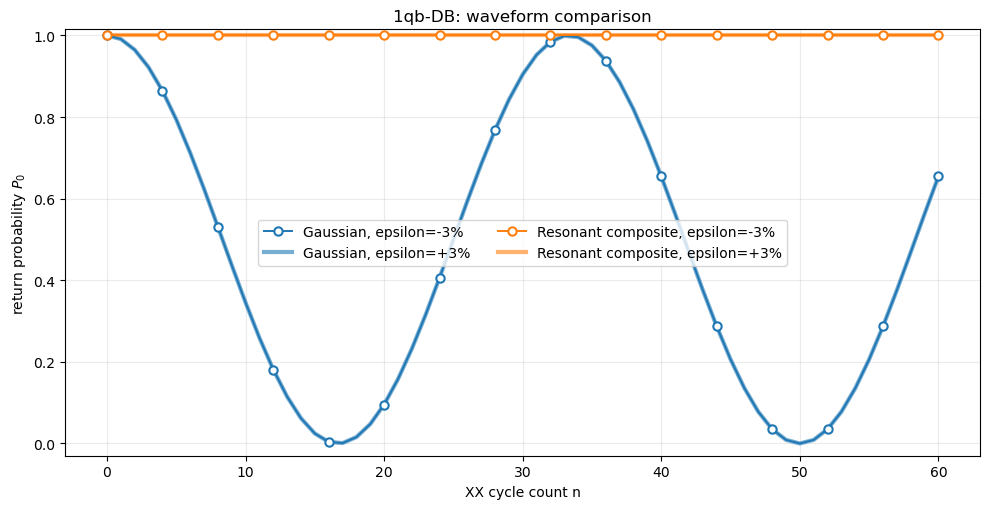

In [24]:
traces, results = db.calculate_db_results(
    pulses, gates, ERRORS, N_CYCLES
)
db.plot_db_comparison(traces, N_CYCLES)

In [25]:
db.print_results_table(results, ERRORS)

pulse                  error         F_gate      P0(final)       Delta P0
---------------------------------------------------------------------------
Gaussian                 -3% 0.998520653017    0.654511864   1.000000e+00
Gaussian                 +3% 0.998520656833    0.654504923   1.000000e+00
Resonant composite       -3% 0.999999999822    0.999996147   3.852586e-06
Resonant composite       +3% 0.999999999822    0.999996147   3.852584e-06


## 5. Reproducibility checks

Compare this independent Hamiltonian propagation with the saved waveform metadata.

In [26]:
db.validate_results(metadata, gates, results, ERRORS, N_CYCLES)
print("All Hamiltonian-evolution, metadata, and DB checks passed.")

All Hamiltonian-evolution, metadata, and DB checks passed.


## 6 Noisy transmon simulation

This section is the real noisy DB simulation on transmons. 
There are few things need to specify:
1. The $\Omega(t)$ and $t$ are unitless; we should scale them (while their integration is fixed) to cater the transmon's gate time etc. [I propose gate time is 50ns, reasonable?]. 
2. For the Gaussian pulse, it is purly $X$, should we do DRAG along $Y$ (for leakage suppresion)? [geometric curve control seems DRAG incompatible]
3. The injection of the control error specify the total control Hamiltonian. But noisy simulation should add more.
4. For transmons: there are (i) 3rd level which will give leakage, (ii) add Lindblad simulation based on physically-meaningful $T_1,T_2$ data? I hope if it is doable, we should resort to ready libary like `qutip` or `qiskit`. I stronlgy not recommend write them ourself.

Then the revival probablity is based on the noisy simulation. 

## Conclusion

At $\pm3\%$ amplitude error, the Gaussian covers essentially the full $P_0$ range within 60 cycles. The resonant composite pulse suppresses the simulated variation to approximately $3.9\times10^{-6}$ while retaining near-unit $X_\pi$ fidelity.